In [5]:
# ==== XGBoost training with live logs (version-agnostic via xgboost.train) ====
import os, json, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

import xgboost as xgb

# --- config ---
INPUT_CSV  = "/Users/alexpotter/AIoT-Lab/Datapreprocessing/Temp_combined_features.csv"
OUTPUT_DIR = "/Users/alexpotter/AIoT-Lab/Training/Temp_Adjust/Model"
HORIZON    = 1  # predict next-step indoor temp

REQUIRED_TIME_COL = "Timestamp"
REQUIRED_FEATURE_COLS = [
    "Indoor_Temperature_C",
    "Indoor_RH_Percent",
    "Outdoor_Temp_C",
    "Dewpoint_Temp_C",
    "Solar_Radiation_DNI_W_m2",
    "HVAC_Energy_usage_KWh",
]
os.makedirs(OUTPUT_DIR, exist_ok=True)

# --- load + target ---
df = pd.read_csv(INPUT_CSV)

# chronological order if timestamp present
ts = pd.to_datetime(df[REQUIRED_TIME_COL], errors="coerce", infer_datetime_format=True)
if ts.notna().any():
    df = df.assign(_ts=ts).sort_values("_ts").drop(columns="_ts").reset_index(drop=True)

# numeric features
for c in REQUIRED_FEATURE_COLS:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df["Indoor_Temperature_C"] = pd.to_numeric(df["Indoor_Temperature_C"], errors="coerce")
df["target_Indoor_Temperature_C_next"] = df["Indoor_Temperature_C"].shift(-HORIZON)
df = df.dropna(subset=["target_Indoor_Temperature_C_next"])

# simple time features (keep raw Timestamp out of model)
ts2 = pd.to_datetime(df[REQUIRED_TIME_COL], errors="coerce")
df["Hour"] = ts2.dt.hour
df["DayOfWeek"] = ts2.dt.dayofweek
df["Month"] = ts2.dt.month
feature_cols = REQUIRED_FEATURE_COLS + ["Hour", "DayOfWeek", "Month"]

# split 80/20 chronologically
n = len(df); split_idx = int(n * 0.8)
train_df = df.iloc[:split_idx].copy()
test_df  = df.iloc[split_idx:].copy()

X_train = train_df[feature_cols].apply(pd.to_numeric, errors="coerce").values
y_train = train_df["target_Indoor_Temperature_C_next"].astype(float).values
X_test  = test_df[feature_cols].apply(pd.to_numeric, errors="coerce").values
y_test  = test_df["target_Indoor_Temperature_C_next"].astype(float).values




/var/folders/lw/kvyfkfps3wl6qfd2k99747yh0000gn/T/ipykernel_24668/4159499272.py:31: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  ts = pd.to_datetime(df[REQUIRED_TIME_COL], errors="coerce", infer_datetime_format=True)


Training XGBoost with live logs every 10 rounds (DMatrix API)...
[0]	train-rmse:2.63905	train-mae:1.55027	valid-rmse:1.45397	valid-mae:1.04494
[10]	train-rmse:1.64600	train-mae:0.97006	valid-rmse:0.96359	valid-mae:0.70246
[20]	train-rmse:1.01598	train-mae:0.60928	valid-rmse:0.69164	valid-mae:0.51025
[30]	train-rmse:0.62756	train-mae:0.38320	valid-rmse:0.51853	valid-mae:0.38271
[40]	train-rmse:0.40556	train-mae:0.25273	valid-rmse:0.43916	valid-mae:0.31940
[50]	train-rmse:0.26590	train-mae:0.17071	valid-rmse:0.39017	valid-mae:0.27977
[60]	train-rmse:0.20072	train-mae:0.13137	valid-rmse:0.38456	valid-mae:0.27202
[70]	train-rmse:0.15217	train-mae:0.10106	valid-rmse:0.36203	valid-mae:0.25375
[80]	train-rmse:0.12443	train-mae:0.08279	valid-rmse:0.34452	valid-mae:0.24037
[90]	train-rmse:0.10821	train-mae:0.07183	valid-rmse:0.33149	valid-mae:0.23059
[100]	train-rmse:0.09694	train-mae:0.06406	valid-rmse:0.31942	valid-mae:0.22046
[110]	train-rmse:0.08833	train-mae:0.05860	valid-rmse:0.30677	vali

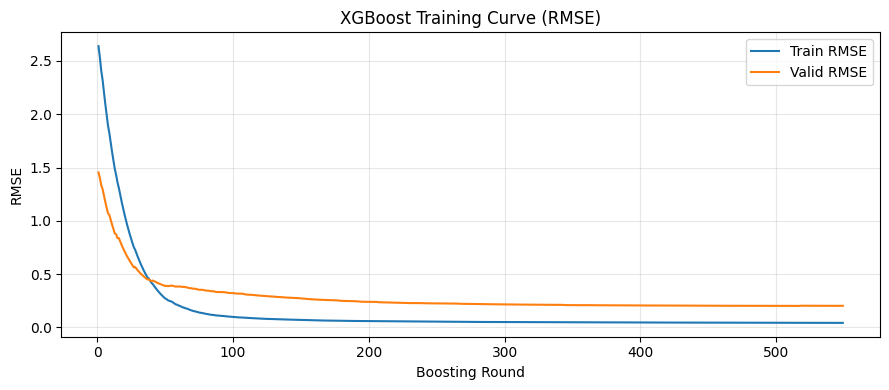

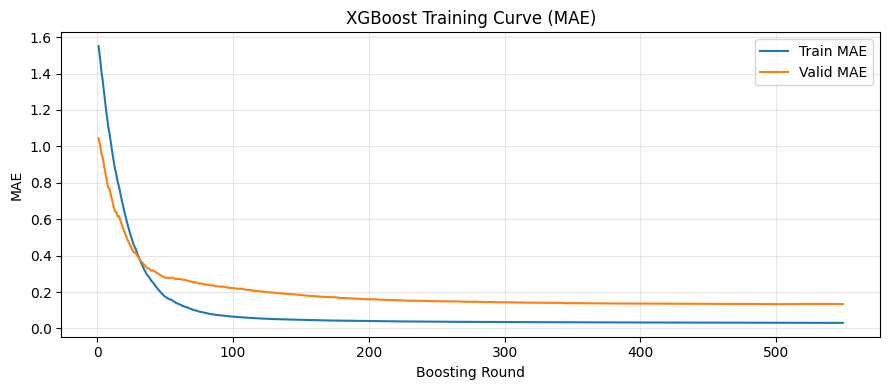

Saved model to: /Users/alexpotter/AIoT-Lab/Training/Temp_Adjust/Model/xgboost_regressor.json


In [6]:
# --- DMatrix and params ---
dtrain = xgb.DMatrix(X_train, label=y_train, feature_names=feature_cols)
dtest  = xgb.DMatrix(X_test,  label=y_test,  feature_names=feature_cols)

params = {
    "objective": "reg:squarederror",
    "max_depth": 6,
    "eta": 0.05,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "reg_alpha": 0.0,
    "reg_lambda": 1.0,
    "tree_method": "hist",
    "eval_metric": ["rmse", "mae"],   # multiple metrics supported here
    "seed": 42,
}

num_boost_round = 1000
early_stopping_rounds = 50
evals_result = {}
watchlist = [(dtrain, "train"), (dtest, "valid")]

print("Training XGBoost with live logs every 10 rounds (DMatrix API)...")
t0 = time.time()
bst = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=num_boost_round,
    evals=watchlist,
    evals_result=evals_result,
    verbose_eval=10,                  # <-- prints every 10 rounds
    early_stopping_rounds=early_stopping_rounds,
)
t1 = time.time()
print(f"Training finished in {t1 - t0:.2f}s. Best iteration: {bst.best_iteration}")

# --- metrics on the best iteration (version-safe) ---
# Prefer best_iteration if available; +1 because ntree_limit counts trees
best_iter = None
try:
    best_iter = int(bst.best_iteration)
except Exception:
    # some very old builds store it as a string attr or not at all
    try:
        best_iter = int(bst.attr("best_iteration"))
    except Exception:
        best_iter = None  # no early-stopping info available

y_pred = None
if best_iter is not None and best_iter >= 0:
    # Try new API first
    try:
        y_pred = bst.predict(dtest, iteration_range=(0, best_iter + 1))
        used_limit = f"iteration_range=(0, {best_iter+1})"
    except TypeError:
        # Older API: use ntree_limit
        y_pred = bst.predict(dtest, ntree_limit=best_iter + 1)
        used_limit = f"ntree_limit={best_iter+1}"
else:
    # No best_iter info; use full model
    try:
        y_pred = bst.predict(dtest)  # all trees
        used_limit = "all trees"
    except TypeError:
        # very old xgb might still want ntree_limit, guess with num_boost_round
        y_pred = bst.predict(dtest, ntree_limit=num_boost_round)
        used_limit = f"ntree_limit={num_boost_round}"

metrics = {
    "MAE": float(mean_absolute_error(y_test, y_pred)),
    "RMSE": float(np.sqrt(mean_squared_error(y_test, y_pred))),
    "R2": float(r2_score(y_test, y_pred)),
    "best_iteration": (None if best_iter is None else int(best_iter)),
    "used_limit": used_limit,
}
print("Final XGB test metrics:", metrics)


# --- plots from evals_result ---
train_rmse = evals_result["train"]["rmse"]
valid_rmse = evals_result["valid"]["rmse"]
train_mae  = evals_result["train"]["mae"]
valid_mae  = evals_result["valid"]["mae"]
rounds = range(1, len(train_rmse) + 1)

plt.figure(figsize=(9,4))
plt.plot(rounds, train_rmse, label="Train RMSE")
plt.plot(rounds, valid_rmse, label="Valid RMSE")
plt.title("XGBoost Training Curve (RMSE)")
plt.xlabel("Boosting Round")
plt.ylabel("RMSE")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(9,4))
plt.plot(rounds, train_mae, label="Train MAE")
plt.plot(rounds, valid_mae, label="Valid MAE")
plt.title("XGBoost Training Curve (MAE)")
plt.xlabel("Boosting Round")
plt.ylabel("MAE")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# --- save booster + metrics ---
# Save native XGBoost model (JSON is preferred format)
model_path = os.path.join(OUTPUT_DIR, "xgboost_regressor.json")
bst.save_model(model_path)
with open(os.path.join(OUTPUT_DIR, "metrics_xgb.json"), "w") as f:
    json.dump(metrics, f, indent=2)
print("Saved model to:", model_path)